In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from ultralytics import SAM
import os
from PIL import Image

# 解除 Pillow 的图片像素总数限制（设为 None 表示无上限）
Image.MAX_IMAGE_PIXELS = None

In [2]:
class MineralRLProcessor:
    """矿物图像分割与特征提取处理器：基于SAM3模型实现矿物区域分割，提取几何/颜色特征，输出可视化结果和特征CSV文件"""
    def __init__(self, model_path='./facebook_sam3/sam3.pt'):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f"正在加载模型至 {self.device}... (已针对RTX 3060等GPU优化显存管理)")
        self.model = SAM(model_path)

    def _generate_grid_points(self, h, w, grid_size=64):
        """生成网格提示点"""
        x = np.linspace(20, w - 20, grid_size)
        y = np.linspace(20, h - 20, grid_size)
        xv, yv = np.meshgrid(x, y)
        return np.stack([xv.flatten(), yv.flatten()], axis=1).astype(np.float32).tolist()

    def _nms_masks(self, boxes, scores, iou_threshold=0.5):
        """NMS去重"""
        if len(boxes) == 0:
            return []
        x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
        areas = (x2 - x1) * (y2 - y1)
        order = scores.argsort()[::-1]
        keep = []
        while order.size > 0:
            i = order[0]
            keep.append(i)
            xx1 = np.maximum(x1[i], x1[order[1:]])
            yy1 = np.maximum(y1[i], y1[order[1:]])
            xx2 = np.minimum(x2[i], x2[order[1:]])
            yy2 = np.minimum(y2[i], y2[order[1:]])
            w_inter = np.maximum(0.0, xx2 - xx1)
            h_inter = np.maximum(0.0, yy2 - yy1)
            inter = w_inter * h_inter
            ovr = inter / (areas[i] + areas[order[1:]] - inter)
            inds = np.where(ovr <= iou_threshold)[0]
            order = order[inds + 1]
        return keep

    def run_pipeline(self, image_path, save_dir='output', batch_size=32, max_side=1288):
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

        # ========== 使用 PIL 安全读取超大图像并缩放 ==========
        try:
            pil_img = Image.open(image_path)          # 只读文件头，不解码
            orig_w, orig_h = pil_img.size
            print(f"原始图像尺寸: {orig_w} x {orig_h}")

            # 计算缩放目标尺寸
            scale = 1.0
            if max(orig_w, orig_h) > max_side:
                scale = max_side / max(orig_w, orig_h)
                new_w = int(orig_w * scale)
                new_h = int(orig_h * scale)
            else:
                new_w, new_h = orig_w, orig_h

            # 使用 draft 降采样：在解码时直接丢弃高频细节，减少内存
            draft_factor = 1
            while (orig_w // (draft_factor * 2) >= new_w and
                   orig_h // (draft_factor * 2) >= new_h):
                draft_factor *= 2

            if draft_factor > 1:
                pil_img.draft('RGB', (orig_w // draft_factor, orig_h // draft_factor))
                print(f"应用 draft 降采样因子: {draft_factor}，内存消耗降低为 1/{draft_factor**2}")

            # 调整到精确尺寸
            pil_img = pil_img.resize((new_w, new_h), Image.LANCZOS)

            # 转为 OpenCV 的 BGR 格式（用于颜色特征提取和可视化）
            img_bgr = np.array(pil_img)
            img_bgr = cv2.cvtColor(img_bgr, cv2.COLOR_RGB2BGR)
            h, w = img_bgr.shape[:2]
            print(f"处理后图像尺寸: {w} x {h} (缩放因子: {scale:.4f})")

            # 同时也准备一份 RGB 格式，直接供 SAM 模型使用，避免再次读取原图
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        except Exception as e:
            raise RuntimeError(f"图像读取失败: {e}")

        # ========== 生成网格提示点 ==========
        all_points = self._generate_grid_points(h, w, grid_size=48)
        all_raw_masks = []
        all_raw_boxes = []
        all_raw_scores = []

        print(f"开始分批次处理，每批 {batch_size} 个点，以防止显存溢出...")

        # ========== 分批次 SAM 预测 ==========
        for i in range(0, len(all_points), batch_size):
            batch_pts = all_points[i: i + batch_size]
            batch_labels = [1] * len(batch_pts)
            # batch_labels = [1] * (len(batch_pts)//2) + [0] * (len(batch_pts)//2)

            torch.cuda.empty_cache()

            # 直接传入 numpy 数组 img_rgb，避免 SAM 内部再读超大原图
            results = self.model.predict(
                source=img_rgb,           # 关键：传入内存中的 RGB 图像
                points=batch_pts,
                labels=batch_labels,
                conf=0.15,
                imgsz=max_side,           # 使用最大边长作为模型输入尺寸
                retina_masks=True,
                device=self.device,
                verbose=False
            )

            result = results[0]
            if result.masks is not None:
                all_raw_masks.append(result.masks.data.cpu().numpy())
                all_raw_boxes.append(result.boxes.xyxy.cpu().numpy())
                all_raw_scores.append(result.boxes.conf.cpu().numpy())

            if (i // batch_size) % 5 == 0:
                print(f"进度: {i}/{len(all_points)} 点已处理...")

        if not all_raw_masks:
            print("警告：未检测到任何矿物对象，退出。")
            return

        # ========== 拼接与去重 ==========
        masks_concat = np.concatenate(all_raw_masks, axis=0)
        boxes_concat = np.concatenate(all_raw_boxes, axis=0)
        scores_concat = np.concatenate(all_raw_scores, axis=0)

        print(f"正在对 {len(masks_concat)} 个候选掩码进行全局去重...")
        keep_idx = self._nms_masks(boxes_concat, scores_concat, iou_threshold=0.5)

        # ========== 特征提取 ==========
        object_data = []
        mask_overlay = np.zeros_like(img_bgr)
        hsv_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

        for idx in keep_idx:
            m_uint8 = masks_concat[idx].astype(np.uint8)
            if m_uint8.shape[:2] != (h, w):
                m_uint8 = cv2.resize(m_uint8, (w, h), interpolation=cv2.INTER_NEAREST)

            area = np.sum(m_uint8)
            if area < 100:
                continue

            contours, _ = cv2.findContours(m_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not contours:
                continue

            cnt = contours[0]
            M = cv2.moments(cnt)
            if M['m00'] == 0:
                continue

            # 归一化中心坐标
            cx = (M['m10'] / M['m00']) / w
            cy = (M['m01'] / M['m00']) / h

            cnt_area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)

            # 长宽比
            if len(cnt) >= 5:
                rect = cv2.minAreaRect(cnt)
                rect_width, rect_height = rect[1]
                if rect_width == 0 or rect_height == 0:
                    continue
                aspect_ratio = max(rect_width, rect_height) / min(rect_width, rect_height)
            else:
                aspect_ratio = 1.0

            # 紧凑度
            compactness = (4 * np.pi * cnt_area) / (perimeter * perimeter) if perimeter > 0 else 0

            # 颜色特征（基于掩码区域）
            mean_hsv = cv2.mean(hsv_img, mask=m_uint8)[:3]
            mean_bgr = cv2.mean(img_bgr, mask=m_uint8)[:3]

            object_data.append({
                "state_area_ratio": round(area / (h * w), 4),
                "state_cx": round(cx, 4),
                "state_cy": round(cy, 4),
                "state_aspect_ratio": round(min(aspect_ratio / 10.0, 1.0), 4),
                "state_compactness": round(compactness, 4),
                "state_h": round(mean_hsv[0] / 180, 4),
                "state_s": round(mean_hsv[1] / 255, 4),
                "state_v": round(mean_hsv[2] / 255, 4),
                "state_b": round(mean_bgr[0] / 255, 4),
                "state_g": round(mean_bgr[1] / 255, 4),
                "state_r": round(mean_bgr[2] / 255, 4),
            })

            # 可视化随机颜色
            color = [np.random.randint(0, 255) for _ in range(3)]
            mask_overlay[m_uint8 > 0] = color

        # ========== 保存结果 ==========
        cv2.imwrite(f"{save_dir}/final_mineral_rl_view.jpg",
                    cv2.addWeighted(img_bgr, 0.5, mask_overlay, 0.5, 0))
        pd.DataFrame(object_data).to_csv(f"{save_dir}/mineral_states_for_rl.csv", index=False)
        print(f"最终提取出 {len(object_data)} 个独立矿物对象，特征已保存至 {save_dir}/mineral_states_for_rl.csv。")

    def generate_summary_report(self, input_data, save_path="./output/stats_report.png"):
        plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.rcParams['axes.unicode_minus'] = False

        if isinstance(input_data, str):
            print(f"正在从文件加载数据: {input_data}")
            df = pd.read_csv(input_data)
        elif isinstance(input_data, list):
            df = pd.DataFrame(input_data)
        else:
            print("错误：不支持的数据类型！")
            return

        if df.empty:
            print("警告：数据为空。")
            return

        total_count = len(df)
        total_area_ratio = df['state_area_ratio'].sum()
        avg_compactness = df['state_compactness'].mean()

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # 饼图
        mineral_ratio = min(total_area_ratio, 1.0)
        labels = ['矿物颗粒', '背景区域']
        sizes = [mineral_ratio, 1.0 - mineral_ratio]
        colors = ['#ff9999', '#eeeeee']
        axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
                    colors=colors, explode=(0.05, 0), shadow=True)
        axes[0].set_title(f"矿物颗粒面积占比 (总数: {total_count}个)", fontsize=14)

        # 直方图
        axes[1].hist(df['state_area_ratio'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[1].set_title("矿物颗粒尺寸分布直方图", fontsize=14)
        axes[1].set_xlabel("归一化面积占比", fontsize=12)
        axes[1].set_ylabel("出现频数", fontsize=12)
        axes[1].grid(axis='y', linestyle='--', alpha=0.6)

        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        print(f"统计图表已保存至: {save_path}")
        plt.show()

正在加载模型至 cuda... (已针对RTX 3060等GPU优化显存管理)
原始图像尺寸: 64848 x 47988
应用 draft 降采样因子: 32，内存消耗降低为 1/1024
处理后图像尺寸: 1288 x 953 (缩放因子: 0.0199)
开始分批次处理，每批 32 个点，以防止显存溢出...
进度: 0/2304 点已处理...
进度: 160/2304 点已处理...
进度: 320/2304 点已处理...
进度: 480/2304 点已处理...
进度: 640/2304 点已处理...
进度: 800/2304 点已处理...
进度: 960/2304 点已处理...
进度: 1120/2304 点已处理...
进度: 1280/2304 点已处理...
进度: 1440/2304 点已处理...
进度: 1600/2304 点已处理...
进度: 1760/2304 点已处理...
进度: 1920/2304 点已处理...
进度: 2080/2304 点已处理...
进度: 2240/2304 点已处理...
正在对 2130 个候选掩码进行全局去重...
最终提取出 430 个独立矿物对象，特征已保存至 output/mineral_states_for_rl.csv。
正在从文件加载数据: ./output/mineral_states_for_rl.csv
统计图表已保存至: ./output/stats_report.png


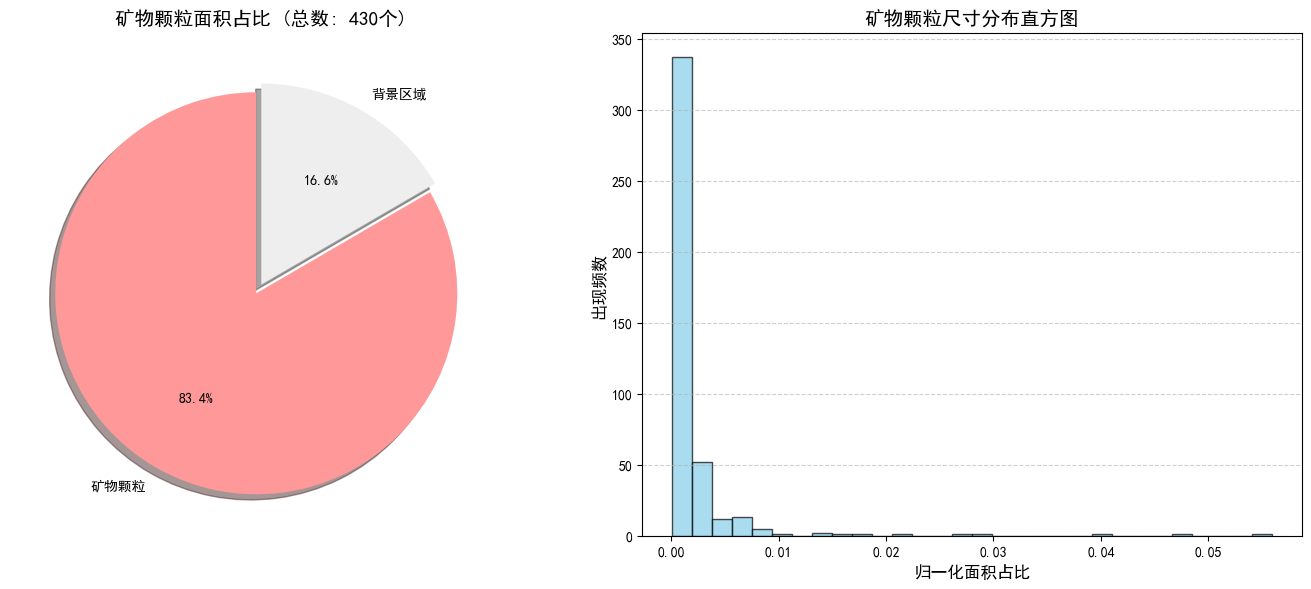

In [3]:
processor = MineralRLProcessor()
processor.run_pipeline("./data/img_mosaic_big.jpg")
processor.generate_summary_report("./output/mineral_states_for_rl.csv")